In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os
import glob
import re

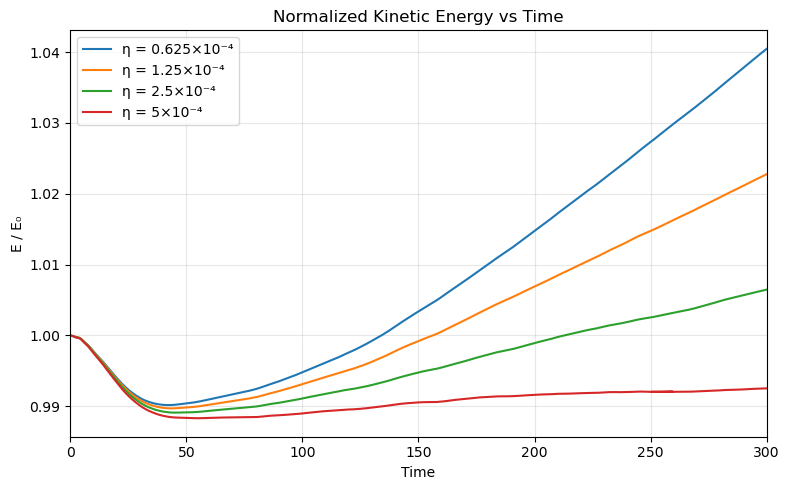

In [2]:
# --- File paths ---
File_Eki = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnKi1_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnKi1_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnKi1_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnKi1_ApJ_.h5'
]

File_Time = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/Time_ApJ_.h5'
]

labels = [
    'η = 0.625×10⁻⁴',
    'η = 1.25×10⁻⁴',
    'η = 2.5×10⁻⁴',
    'η = 5×10⁻⁴'
]

# Helper function to load DS1 from a file
def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]        # get first dataset name, e.g. 'DS1'
        return f[key][:]

# --- Load all runs ---
energies = []
times = []
for efile, tfile in zip(File_Eki, File_Time):
    energies.append(load_dataset(efile))
    times.append(load_dataset(tfile))

# --- Normalize energies ---
normalized = [E / E[0] for E in energies]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.xlim(0, 300) 
# plt.ylim(0.98, 1.02)

for t, Enorm, label in zip(times, normalized, labels):
    plt.plot(t, Enorm, label=label)

plt.xlabel("Time")
plt.ylabel("E / E₀")
plt.title("Normalized Kinetic Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("KineticEnergyPlot.png", dpi=300)
plt.show()

In [3]:
#Testing if total energy = magnetic energy + kinetic energy

File_Emag = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnMa_ApJ_.h5'
]

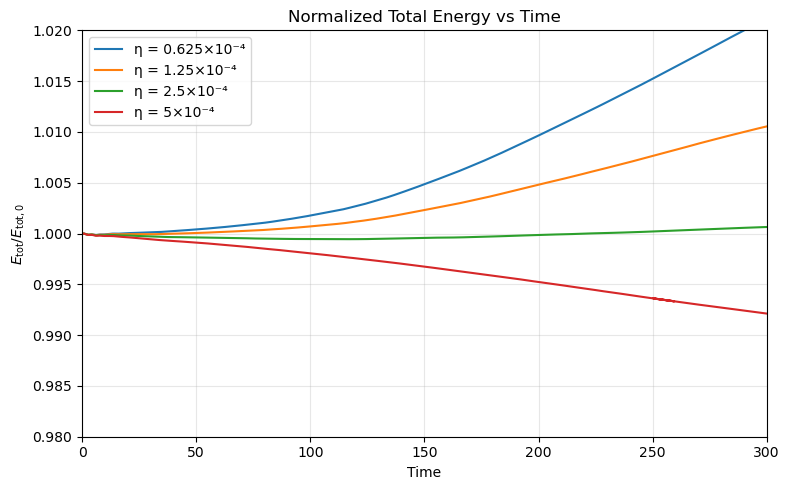

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# --- Helper function ---
def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]
        return f[key][:]

# --- Load all runs ---
Emag, Ekin, times = [], [], []

for fmag, fkin, ftime in zip(File_Emag, File_Eki, File_Time):
    Emag.append(load_dataset(fmag))
    Ekin.append(load_dataset(fkin))
    times.append(load_dataset(ftime))

# --- Compute total energy ---
Etot = [Em + Ek for Em, Ek in zip(Emag, Ekin)]

# --- Normalize ---
Etot_norm = [E / E[0] for E in Etot]
Emag_norm = [E / E[0] for E in Emag]
Ekin_norm = [E / E[0] for E in Ekin]

# --- Plot total energy ---
plt.figure(figsize=(8, 5))
plt.xlim(0, 300)
plt.ylim(0.98, 1.02)

for t, En, label in zip(times, Etot_norm, labels):
    plt.plot(t, En, label=label)

plt.xlabel("Time")
plt.ylabel(r"$E_{\mathrm{tot}} / E_{\mathrm{tot},0}$")
plt.title("Normalized Total Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("TotalEnergyPlot.png", dpi=300)
plt.show()

In [5]:
File_Etot = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnTot_ApJ_.h5'
]

import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]
        return f[key][:]

# --- Load all energies ---
Emag, Ekin, Etot, times = [], [], [], []

for fmag, fkin, ftot, ftime in zip(File_Emag, File_Eki, File_Etot, File_Time):
    Emag.append(load_dataset(fmag))
    Ekin.append(load_dataset(fkin))
    Etot.append(load_dataset(ftot))
    times.append(load_dataset(ftime))

# --- Construct total from components ---
Etot_from_parts = [Em + Ek for Em, Ek in zip(Emag, Ekin)]

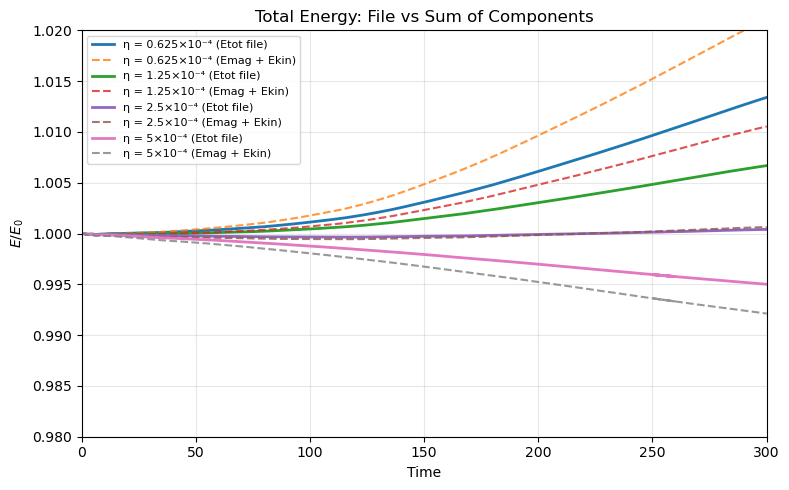

In [6]:
plt.figure(figsize=(8, 5))
plt.xlim(0, 300)
plt.ylim(0.98, 1.02)

for t, Et_file, Et_parts, label in zip(
        times, Etot, Etot_from_parts, labels):

    plt.plot(t, Et_file / Et_file[0],
             lw=2, label=label + " (Etot file)")

    plt.plot(t, Et_parts / Et_parts[0],
             ls="--", lw=1.5, alpha=0.8,
             label=label + " (Emag + Ekin)")

plt.xlabel("Time")
plt.ylabel(r"$E / E_0$")
plt.title("Total Energy: File vs Sum of Components")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("TotalEnergyComparison.png", dpi=300)
plt.show()

In [7]:
colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
]

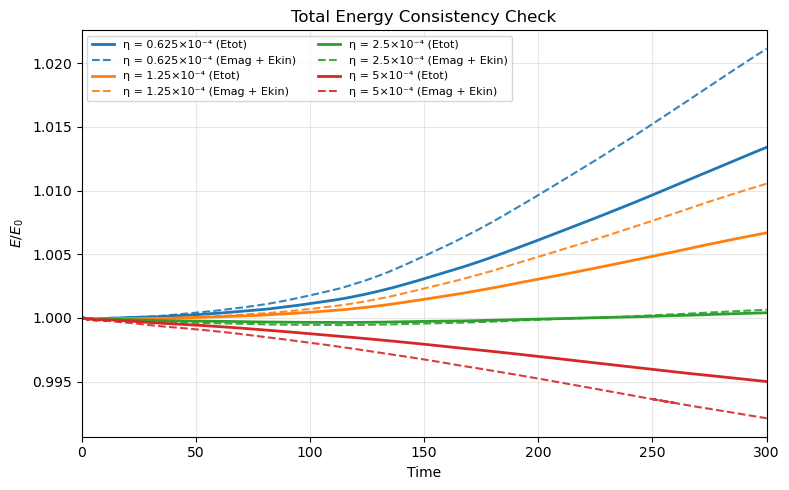

In [8]:
plt.figure(figsize=(8, 5))
plt.xlim(0, 300)

for t, Et_file, Et_parts, label, color in zip(
        times, Etot, Etot_from_parts, labels, colors):

    # Total energy from file
    plt.plot(
        t,
        Et_file / Et_file[0],
        color=color,
        lw=2,
        label=f"{label} (Etot)"
    )

    # Sum of magnetic + kinetic
    plt.plot(
        t,
        Et_parts / Et_parts[0],
        color=color,
        lw=1.5,
        ls="--",
        alpha=0.9,
        label=f"{label} (Emag + Ekin)"
    )

plt.xlabel("Time")
plt.ylabel(r"$E / E_0$")
plt.title("Total Energy Consistency Check")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("TotalEnergyComparison.png", dpi=300)
plt.show()

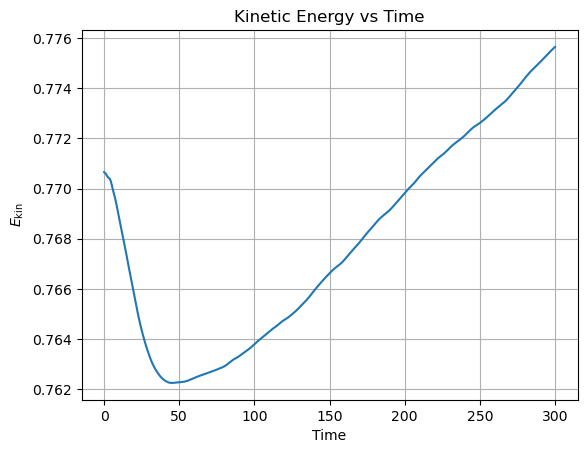

In [9]:
EKin_file = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnKi1_ApJ_.h5'
Time_file = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5'



with h5py.File(EKin_file, 'r') as f:
    Ekin = f[list(f.keys())[0]][:]

with h5py.File(Time_file, 'r') as f:
    time = f[list(f.keys())[0]][:]

plt.figure()
plt.plot(time, Ekin)
plt.xlabel('Time')
plt.ylabel(r'$E_{\mathrm{kin}}$')
plt.title('Kinetic Energy vs Time')
plt.grid(True)
plt.show()

In [10]:
vel_dir = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'

def extract_timestep(fname):
    return int(re.search(r'_t(\d+)\.h5$', fname).group(1))

Ux_files = glob.glob(os.path.join(vel_dir, 'Ux1_ApJ_t*.h5'))
Ux_files = sorted(Ux_files, key=extract_timestep)

Ekin_from_U = []
timesteps = []

for ux_file in Ux_files:
    t = extract_timestep(ux_file)
    timesteps.append(t)

    uy_file = os.path.join(vel_dir, f'Uy1_ApJ_t{t}.h5')
    uz_file = os.path.join(vel_dir, f'Uz1_ApJ_t{t}.h5')

    n_file = os.path.join(vel_dir, f'Dn1_ApJ_t{t}.h5')

    with h5py.File(ux_file, 'r') as f:
        Ux = f[list(f.keys())[0]][:]

    with h5py.File(uy_file, 'r') as f:
        Uy = f[list(f.keys())[0]][:]

    with h5py.File(uz_file, 'r') as f:
        Uz = f[list(f.keys())[0]][:]

    with h5py.File(n_file, 'r') as f:
        n = f[list(f.keys())[0]][:]

    Ux = Ux/n
    Uy = Uy/n
    Uz = Uz/n

    Ekin_t = 0.5 * np.sum(Ux**2 + Uy**2 + Uz**2)
    Ekin_from_U.append(Ekin_t)

    print(ux_file)

Ekin_from_U = np.array(Ekin_from_U)
timesteps = np.array(timesteps)

/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t0.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t1.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t2.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t3.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t4.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t5.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t6.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t7.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t8.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t9.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t10.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t11.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t12.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t13.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t14.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t15.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t16.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048

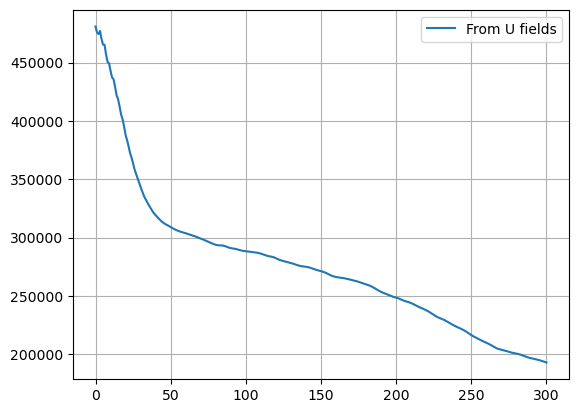

In [12]:
plt.plot(timesteps, Ekin_from_U, label='From U fields')
# plt.plot(time, Ekin, '--', label='From EnKi file')
plt.legend()
plt.grid()
plt.show()